# Exercises, Chapter 13, "Logistic Regression"

In [42]:
import numpy

from matplotlib import pyplot
from scipy import special

## 13.4, Logistic regression with two predictors

> The following logistic regression has been fit:

```
            Median MAD_SD
(Intercept) -1.9    0.6
x            0.7    0.8
z            0.7    0.5
```

> Here, $x$ is a continuous predictor ranging from 0 to 10, and $z$ is a binary
> predictor taking on the values 0 and 1. Display the fitted model as two curves
> on a graph of $\text{Pr}(y = 1)$ vs. $x$.

In [43]:
xs = numpy.arange(0, 10.01, 0.05)
p0 = special.expit(-1.9 + 0.7 * xs)
p1 = special.expit(-1.2 + 0.7 * xs)

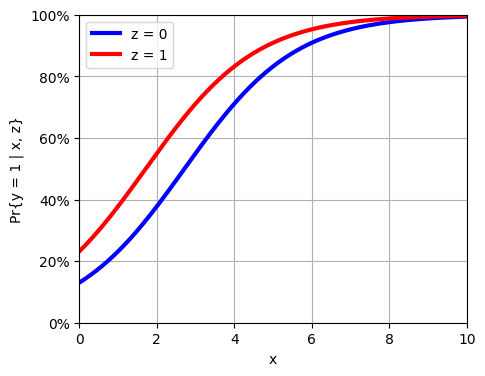

In [50]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(xs, p0, 'b-', label='z = 0', linewidth=3)
ax.plot(xs, p1, 'r-', label='z = 1', linewidth=3)
ax.set_xlabel('x')
ax.set_ylabel('Pr{y = 1 | x, z}')
ax.set_ylim(bottom=0)
ax.set_xlim(0, 10)
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(0, 1)
ax.set_yticks(
    numpy.arange(0, 1.1, 0.2),
    [f'{int(100 * yi)}%' for yi in numpy.arange(0, 1.1, 0.2)],
)
ax.legend()

## 13.7, Graphing a fitted logistic regression

> We downloaded data with weight (in pounds) and age (in years) from a random
> sample of American adults. We then defined a new variable:

`heavy <- weight > 200`

> and fit a logistic regression, predicting heavy from height (in inches):

```
stan_glm(formula = heavy ~ height, family=binomial(link="logit"), data=health)

              Median MAD_SD
(Intercept)  -21.51   1.60
height         0.28   0.02
```

> (a) Graph the logistic regression curve (the probability that someone is
>     heavy) over the approximate range of the data. Be clear where the line
>     goes through the 50% probability point.
>
> (b) Fill in the blank: near the 50% point, comparing two people who differ by
>     one inch in height, you’ll expect a difference of __ in the probability of
>     being heavy.

In [10]:
# Range of heights: 5'0" to 6'6", by quarter inches
heights = numpy.arange(5 * 12, 6 * 12 + 7, 0.25)
heavies = special.expit(-21.51 + 0.28 * heights)

In [20]:
# We cross the 50% line when a + bx = 0
height50 = 21.51 / 0.28
print(f'{height50:0.1f} inches')

76.8 inches


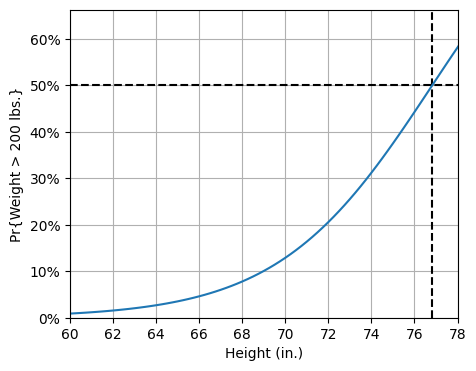

In [40]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.axvline(height50, color='k', linestyle='--')
ax.axhline(0.5, color='k', linestyle='--')
ax.plot(heights, heavies)
ax.set_xlabel('Height (in.)')
ax.set_ylabel('Pr{Weight > 200 lbs.}')
ax.set_ylim(bottom=0)
ax.set_xlim(60, 78)
ax.set_yticks(
    [0.1 * yi for yi in range(7)],
    [f'{10 * yi}%' for yi in range(7)],
)
ax.grid()
ax.set_axisbelow(True)

## 13.9, The algebra of logistic regression with one predictor

> You are interested in how well the combined earnings of the parents in a
> child’s family predicts high school graduation. You are told that the
> probability a child graduates from high school is 27% for children whose
> parents earn no income and is 88% for children whose parents earn 60,000
> dollars.  Determine the logistic regression model that is consistent with this
> information. For simplicity, you may want to assume that income is measured in
> units of 10,000.

In [12]:
a = special.logit(0.27)
b = (special.logit(0.88) - special.logit(0.27)) / 6
print(f'(a, b) = ({a:0.2f}, {b:0.2f})')

(a, b) = (-0.99, 0.50)
